# DESI DR9 kSZ-Cleaned Extended LRG Catalog and n(z) Validation

This notebook validates the DR9 Extended LRG catalog products in this transfer package and documents the theory `n(z)` to use for a single-HOD analysis of the kSZ-cleaned sample.

The key convention is:

- Object-level galaxy maps should use `catalog/valid_for_cl` and `catalog/weight_imaging_mean1` from `data/desi_dr9_extended_velocity_catalogs/desi_dr9_extended_pz*_compact_with_weights.h5`.
- Galaxy selection masks should use the DR9 random-count maps in `data/desi_dr9_imaging_randoms/desi_dr9_randoms_1_0_lrg_quality_count_maps_nside1024_4096.h5`.
- Theory kernels for the final kSZ-cleaned DR9 Extended sample should use `data/desi_dr9_redshift_distributions/desi_dr9_extended_lrg_sigmaz0p05_true_nz.h5`, group `ksz_paper_scaled_counts/dr9_extended_fiducial_outlier_and_photoz_correction_act_overlap`.

The catalog redshift column is `Z_PHOT_MEDIAN`; do not use its histogram as the true-redshift kernel in theory. The calibrated shape comes from the public spectroscopic `N(z)` product, corrected for the `Z_PHOT_STD <= 0.05*(1+Z_PHOT_MEDIAN)` selection. The final kSZ group rescales that calibrated shape to the ACT-overlap, velocity-outlier-cleaned counts reported in the real-space kSZ paper.


In [1]:
from pathlib import Path
import json
import math
import warnings

import h5py
import numpy as np
import matplotlib.pyplot as plt

try:
    import healpy as hp
except ImportError as exc:
    hp = None
    warnings.warn(f"healpy is not available; sky-map cells will not run: {exc}")

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 180,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 10,
})


In [2]:
def find_transfer_root(start=None):
    """Find the transfer package root from the current notebook location."""
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'manifest.json').exists() and (candidate / 'README.md').exists():
            return candidate
    raise FileNotFoundError('Could not find act_desi_ksz_transfer root above the current directory.')

ROOT = find_transfer_root()
OUTDIR = ROOT / 'diagnostics' / 'desi_dr9_ksz_cleaned_catalog'
OUTDIR.mkdir(parents=True, exist_ok=True)

with open(ROOT / 'manifest.json') as f:
    MANIFEST = json.load(f)

CATALOG_PATHS = {
    1: ROOT / 'data/desi_dr9_extended_velocity_catalogs/desi_dr9_extended_pz1_compact_with_weights.h5',
    2: ROOT / 'data/desi_dr9_extended_velocity_catalogs/desi_dr9_extended_pz2_compact_with_weights.h5',
    3: ROOT / 'data/desi_dr9_extended_velocity_catalogs/desi_dr9_extended_pz3_compact_with_weights.h5',
    4: ROOT / 'data/desi_dr9_extended_velocity_catalogs/desi_dr9_extended_pz4_compact_with_weights.h5',
}
NZ_PATH = ROOT / 'data/desi_dr9_redshift_distributions/desi_dr9_extended_lrg_sigmaz0p05_true_nz.h5'
NZ_SUMMARY_PATH = ROOT / 'data/desi_dr9_redshift_distributions/desi_dr9_extended_lrg_sigmaz0p05_true_nz_summary.json'
RANDOM_MAP_PATH = ROOT / 'data/desi_dr9_imaging_randoms/desi_dr9_randoms_1_0_lrg_quality_count_maps_nside1024_4096.h5'

KSZ_GROUP = 'ksz_paper_scaled_counts/dr9_extended_fiducial_outlier_and_photoz_correction_act_overlap'
PHOTOZ_ONLY_GROUP = 'ksz_paper_scaled_counts/dr9_extended_photoz_correction_only_act_overlap'
SHAPE_SOURCE_GROUP = 'zphot_std0p05_spec_ratio_corrected'
PHOTOZ_DIAGNOSTIC_GROUP = 'photoz_histogram_valid_for_cl_diagnostic'

print('Transfer root:', ROOT)
print('Output directory:', OUTDIR)
for path in [*CATALOG_PATHS.values(), NZ_PATH, RANDOM_MAP_PATH]:
    print(path.relative_to(ROOT), 'exists =', path.exists())


Transfer root: /global/cfs/cdirs/lsst/www/shivamp/DESI/act_desi_ksz_transfer
Output directory: /global/cfs/cdirs/lsst/www/shivamp/DESI/act_desi_ksz_transfer/diagnostics/desi_dr9_ksz_cleaned_catalog
data/desi_dr9_extended_velocity_catalogs/desi_dr9_extended_pz1_compact_with_weights.h5 exists = True
data/desi_dr9_extended_velocity_catalogs/desi_dr9_extended_pz2_compact_with_weights.h5 exists = True
data/desi_dr9_extended_velocity_catalogs/desi_dr9_extended_pz3_compact_with_weights.h5 exists = True
data/desi_dr9_extended_velocity_catalogs/desi_dr9_extended_pz4_compact_with_weights.h5 exists = True
data/desi_dr9_redshift_distributions/desi_dr9_extended_lrg_sigmaz0p05_true_nz.h5 exists = True
data/desi_dr9_imaging_randoms/desi_dr9_randoms_1_0_lrg_quality_count_maps_nside1024_4096.h5 exists = True


## What Is Being Validated

The object-level HDF5 catalogs are the DR9 Extended LRG velocity catalogs with DESI public imaging metadata and systematics weights joined onto the original kSZ velocity rows. The default harmonic-space selection is:

```text
valid_for_cl = matched_to_public_dr9 & dr9_lrg_quality_cut & finite_positive_imaging_weight
```

The default object weight is:

```text
weight_imaging_mean1
```

which is the public imaging/systematics weight renormalized to mean 1 inside each tomographic bin after `valid_for_cl`.

The final kSZ-paper cleaned sample has smaller counts because it is in the ACT overlap and includes velocity-outlier cleaning. The transferable object-level catalogs keep the full valid DR9 footprint; the final kSZ abundance is represented in the theory `n(z)` group by scaling the calibrated true-redshift shape to the paper's final counts. If a later object-level analysis needs to exactly reproduce the paper's ACT-overlap/outlier-cleaned object list, that additional cut must be applied consistently during map making.


In [3]:
def as_jsonable(value):
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, dict):
        return {str(k): as_jsonable(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [as_jsonable(v) for v in value]
    return value


def finite_stats(x, percentiles=(0, 1, 5, 16, 50, 84, 95, 99, 100)):
    x = np.asarray(x)
    good = np.isfinite(x)
    out = {'n': int(x.size), 'n_finite': int(good.sum())}
    if not np.any(good):
        return out
    y = x[good].astype(np.float64, copy=False)
    out.update({
        'min': float(np.min(y)),
        'max': float(np.max(y)),
        'mean': float(np.mean(y)),
        'std': float(np.std(y)),
    })
    for p, val in zip(percentiles, np.percentile(y, percentiles)):
        out[f'p{p:g}'] = float(val)
    return out


def weighted_mean_std(x, w):
    x = np.asarray(x, dtype=np.float64)
    w = np.asarray(w, dtype=np.float64)
    good = np.isfinite(x) & np.isfinite(w) & (w > 0)
    if not np.any(good):
        return np.nan, np.nan
    x = x[good]
    w = w[good]
    mean = np.sum(w * x) / np.sum(w)
    var = np.sum(w * (x - mean)**2) / np.sum(w)
    return float(mean), float(np.sqrt(max(var, 0.0)))


def decode_photsys(arr):
    vals, counts = np.unique(arr, return_counts=True)
    return {v.decode() if isinstance(v, bytes) else str(v): int(c) for v, c in zip(vals, counts)}


In [4]:
catalog_stats = {}
for pz, path in CATALOG_PATHS.items():
    print(f'Loading catalog pz{pz}: {path.relative_to(ROOT)}')
    with h5py.File(path, 'r') as f:
        g = f['catalog']
        valid = g['valid_for_cl'][:].astype(bool)
        matched = g['matched_to_public_dr9'][:].astype(bool)
        quality = g['dr9_lrg_quality_cut'][:].astype(bool)
        finite_weight = g['valid_imaging_weight'][:].astype(bool)
        w = g['weight_imaging_mean1'][:][valid]
        w_raw = g['weight_imaging'][:][valid]
        zphot = g['z'][:][valid]
        vr_over_c = g['vr_over_c'][:][valid]
        v_los = g['v_los_km_s'][:][valid]
        mass = g['mass_msun'][:][valid]
        photsys = g['photsys'][:][valid]
        ebv = g['ebv'][:][valid]
        stardens = g['stardens'][:][valid]
        match_arcsec = g['match_arcsec'][:]
        match_z_absdiff = g['match_z_absdiff'][:]
        n_rows = int(g['ra_deg'].shape[0])

    wmean_z, wstd_z = weighted_mean_std(zphot, w)
    catalog_stats[f'pz{pz}'] = {
        'path': str(path.relative_to(ROOT)),
        'n_rows': n_rows,
        'n_valid_for_cl': int(valid.sum()),
        'n_matched_to_public_dr9': int(matched.sum()),
        'n_dr9_lrg_quality_cut': int(quality.sum()),
        'n_valid_imaging_weight': int(finite_weight.sum()),
        'sum_weight_imaging_mean1_valid_for_cl': float(np.sum(w, dtype=np.float64)),
        'mean_weight_imaging_mean1_valid_for_cl': float(np.mean(w)),
        'weighted_mean_photoz': wmean_z,
        'weighted_sigma_photoz': wstd_z,
        'photsys_counts_valid_for_cl': decode_photsys(photsys),
        'weight_imaging_mean1_stats': finite_stats(w),
        'weight_imaging_raw_stats': finite_stats(w_raw),
        'z_phot_median_stats': finite_stats(zphot),
        'vr_over_c_stats': finite_stats(vr_over_c),
        'v_los_km_s_stats': finite_stats(v_los),
        'log10_mass_msun_stats': finite_stats(np.log10(mass[np.isfinite(mass) & (mass > 0)])),
        'ebv_stats': finite_stats(ebv),
        'stardens_stats': finite_stats(stardens),
        'match_arcsec_stats_all_rows': finite_stats(match_arcsec),
        'match_z_absdiff_stats_all_rows': finite_stats(match_z_absdiff),
        'pass_weight_mean1_close_to_one': bool(abs(np.mean(w) - 1.0) < 5e-6),
    }

print(json.dumps(catalog_stats, indent=2)[:6000])


Loading catalog pz1: data/desi_dr9_extended_velocity_catalogs/desi_dr9_extended_pz1_compact_with_weights.h5
Loading catalog pz2: data/desi_dr9_extended_velocity_catalogs/desi_dr9_extended_pz2_compact_with_weights.h5
Loading catalog pz3: data/desi_dr9_extended_velocity_catalogs/desi_dr9_extended_pz3_compact_with_weights.h5
Loading catalog pz4: data/desi_dr9_extended_velocity_catalogs/desi_dr9_extended_pz4_compact_with_weights.h5
{
  "pz1": {
    "path": "data/desi_dr9_extended_velocity_catalogs/desi_dr9_extended_pz1_compact_with_weights.h5",
    "n_rows": 2888832,
    "n_valid_for_cl": 2794391,
    "n_matched_to_public_dr9": 2888832,
    "n_dr9_lrg_quality_cut": 2794391,
    "n_valid_imaging_weight": 2888832,
    "sum_weight_imaging_mean1_valid_for_cl": 2794390.534858942,
    "mean_weight_imaging_mean1_valid_for_cl": 0.9999998211860657,
    "weighted_mean_photoz": 0.47129205107639305,
    "weighted_sigma_photoz": 0.041460431516156394,
    "photsys_counts_valid_for_cl": {
      "N": 7172

In [5]:
with open(NZ_SUMMARY_PATH) as f:
    prepared_nz_summary = json.load(f)

nz_validation = {}
with h5py.File(NZ_PATH, 'r') as f:
    zmid = f['redshift_bins/zmid'][:]
    dz = f['redshift_bins/dz'][:]
    for pz in range(1, 5):
        key = f'pz{pz}'
        g = f[f'{KSZ_GROUP}/{key}']
        nz = g['nz_unit_integral'][:]
        n_count = g['n_per_redshift_bin_count'][:]
        dndz_count = g['dndz_count'][:]
        source_nz = f[f'{SHAPE_SOURCE_GROUP}/{key}/nz_unit_integral'][:]
        photoz_diag = f[f'{PHOTOZ_DIAGNOSTIC_GROUP}/{key}/nz_unit_integral'][:]
        norm = float(np.sum(nz * dz))
        count_sum = float(np.sum(n_count))
        dndz_count_integral = float(np.sum(dndz_count * dz))
        mean_z = float(np.sum(zmid * nz * dz))
        sigma_z = float(np.sqrt(np.sum((zmid - mean_z)**2 * nz * dz)))
        transfer_count = catalog_stats[key]['n_valid_for_cl']
        paper_count = prepared_nz_summary['paper_ksz_counts']['dr9_extended_fiducial_outlier_and_photoz_correction_act_overlap'][key]
        nz_validation[key] = {
            'recommended_group': KSZ_GROUP,
            'normalized_kernel_dataset': 'nz_unit_integral',
            'count_dataset': 'n_per_redshift_bin_count',
            'dndz_count_dataset': 'dndz_count',
            'unit_integral_norm': norm,
            'object_count_sum': count_sum,
            'dndz_count_integral': dndz_count_integral,
            'paper_fiducial_count': int(paper_count),
            'transfer_valid_for_cl_count': int(transfer_count),
            'ksz_count_to_transfer_valid_scale': float(count_sum / transfer_count),
            'mean_true_z': mean_z,
            'sigma_true_z': sigma_z,
            'max_abs_difference_from_shape_source_nz': float(np.max(np.abs(nz - source_nz))),
            'photoz_diagnostic_mean_z': float(np.sum(zmid * photoz_diag * dz)),
        }

print(json.dumps(nz_validation, indent=2))


{
  "pz1": {
    "recommended_group": "ksz_paper_scaled_counts/dr9_extended_fiducial_outlier_and_photoz_correction_act_overlap",
    "normalized_kernel_dataset": "nz_unit_integral",
    "count_dataset": "n_per_redshift_bin_count",
    "dndz_count_dataset": "dndz_count",
    "unit_integral_norm": 0.9999999999999998,
    "object_count_sum": 954820.0,
    "dndz_count_integral": 954820.0,
    "paper_fiducial_count": 954820,
    "transfer_valid_for_cl_count": 2794391,
    "ksz_count_to_transfer_valid_scale": 0.34169162440045076,
    "mean_true_z": 0.46804403957102964,
    "sigma_true_z": 0.058170706735578614,
    "max_abs_difference_from_shape_source_nz": 8.881784197001252e-16,
    "photoz_diagnostic_mean_z": 0.47133207717068837
  },
  "pz2": {
    "recommended_group": "ksz_paper_scaled_counts/dr9_extended_fiducial_outlier_and_photoz_correction_act_overlap",
    "normalized_kernel_dataset": "nz_unit_integral",
    "count_dataset": "n_per_redshift_bin_count",
    "dndz_count_dataset": "dndz_

## Theory n(z) Scaling

For a normalized tracer kernel, use `nz_unit_integral`; every bin integrates to 1. For an abundance-sensitive theory calculation, use `n_per_redshift_bin_count` or `dndz_count` from the same group. These count distributions sum to the real-space kSZ paper's fiducial DR9 Extended ACT-overlap/outlier-cleaned object counts:

```text
pz1:   954,820
pz2: 1,628,650
pz3: 2,125,787
pz4: 1,996,525
```

The count scaling changes abundance, not the calibrated true-redshift shape. This is the cleanest transferable representation available because the reduced kSZ stacking products do not carry object IDs and public imaging weights for an exact object-by-object rejoin.


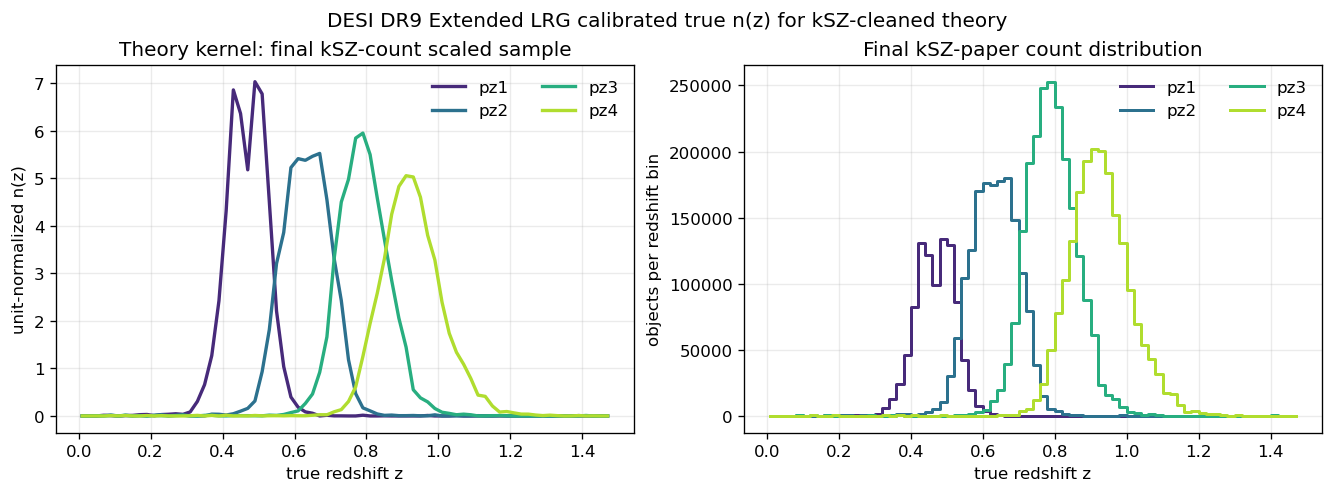

In [6]:
with h5py.File(NZ_PATH, 'r') as f:
    zmid = f['redshift_bins/zmid'][:]
    dz = f['redshift_bins/dz'][:]
    colors = plt.cm.viridis(np.linspace(0.12, 0.88, 4))

    fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
    for pz, color in zip(range(1, 5), colors):
        key = f'pz{pz}'
        nz = f[f'{KSZ_GROUP}/{key}/nz_unit_integral'][:]
        count_dist = f[f'{KSZ_GROUP}/{key}/n_per_redshift_bin_count'][:]
        shape_nz = f[f'{SHAPE_SOURCE_GROUP}/{key}/nz_unit_integral'][:]
        axes[0].plot(zmid, nz, color=color, lw=2, label=f'pz{pz}')
        axes[0].plot(zmid, shape_nz, color=color, lw=1, ls='--', alpha=0.6)
        axes[1].step(zmid, count_dist, where='mid', color=color, lw=1.8, label=f'pz{pz}')

    axes[0].set_xlabel('true redshift z')
    axes[0].set_ylabel('unit-normalized n(z)')
    axes[0].set_title('Theory kernel: final kSZ-count scaled sample')
    axes[0].legend(ncol=2, frameon=False)
    axes[1].set_xlabel('true redshift z')
    axes[1].set_ylabel('objects per redshift bin')
    axes[1].set_title('Final kSZ-paper count distribution')
    axes[1].legend(ncol=2, frameon=False)

    fig.suptitle('DESI DR9 Extended LRG calibrated true n(z) for kSZ-cleaned theory')
    fig.savefig(OUTDIR / 'desi_dr9_ksz_cleaned_nz_validation.png', bbox_inches='tight')
    plt.show()


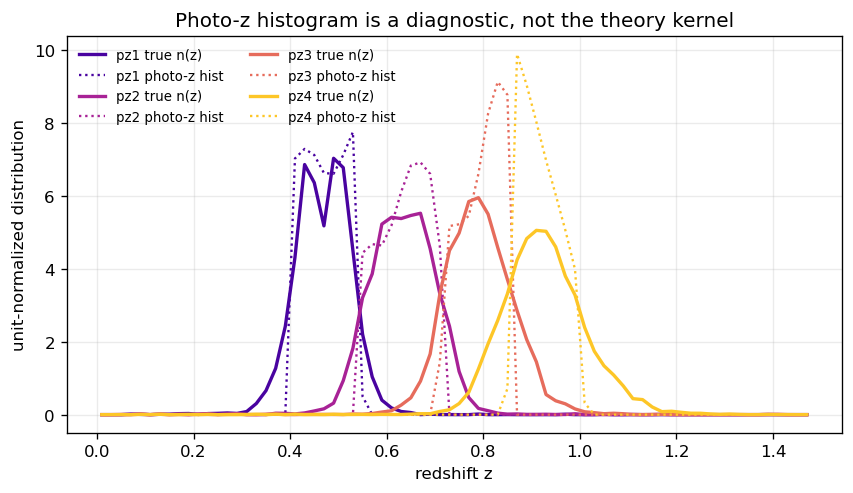

In [7]:
with h5py.File(NZ_PATH, 'r') as f:
    zmid = f['redshift_bins/zmid'][:]
    dz = f['redshift_bins/dz'][:]
    colors = plt.cm.plasma(np.linspace(0.12, 0.88, 4))

    fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
    for pz, color in zip(range(1, 5), colors):
        key = f'pz{pz}'
        true_nz = f[f'{KSZ_GROUP}/{key}/nz_unit_integral'][:]
        photoz_diag = f[f'{PHOTOZ_DIAGNOSTIC_GROUP}/{key}/nz_unit_integral'][:]
        ax.plot(zmid, true_nz, color=color, lw=2, label=f'pz{pz} true n(z)')
        ax.plot(zmid, photoz_diag, color=color, lw=1.4, ls=':', label=f'pz{pz} photo-z hist')

    ax.set_xlabel('redshift z')
    ax.set_ylabel('unit-normalized distribution')
    ax.set_title('Photo-z histogram is a diagnostic, not the theory kernel')
    ax.legend(ncol=2, fontsize=8, frameon=False)
    fig.savefig(OUTDIR / 'desi_dr9_photoz_vs_true_nz_diagnostic.png', bbox_inches='tight')
    plt.show()


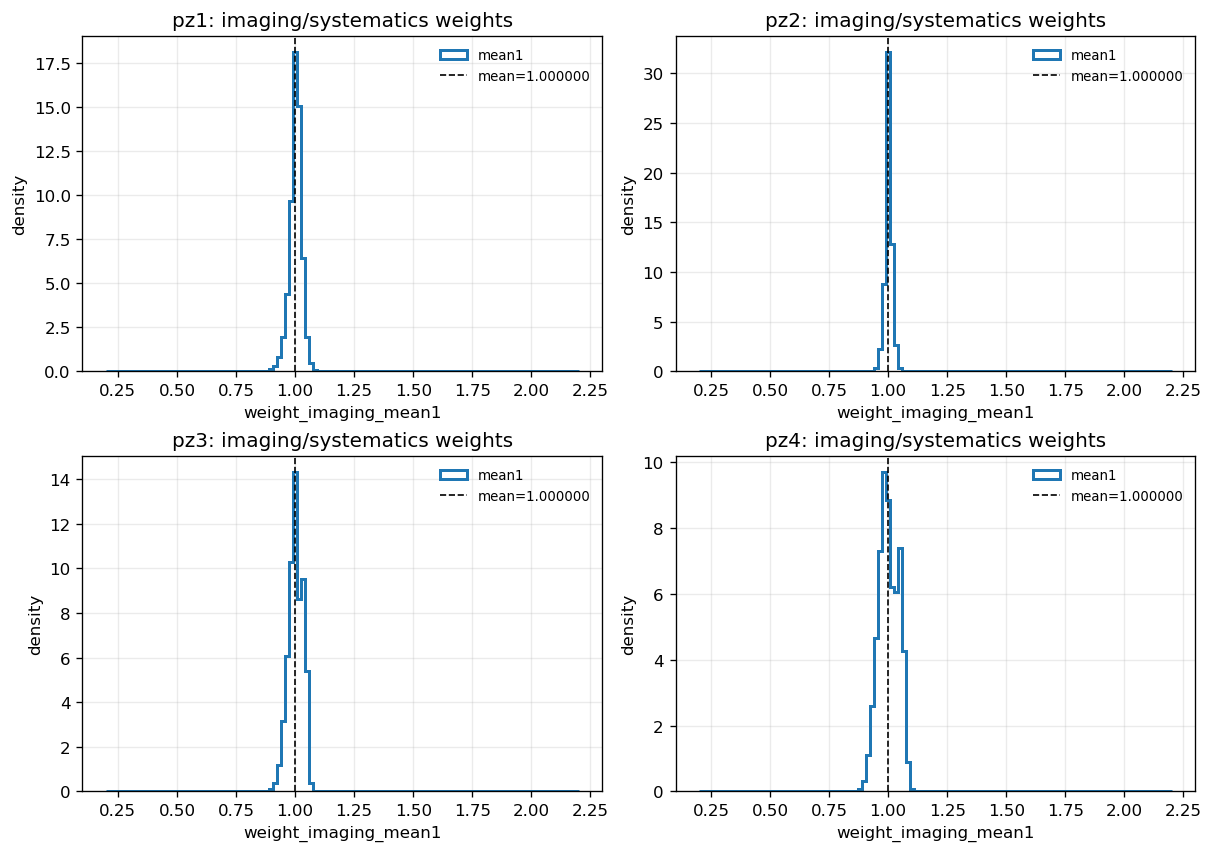

{
  "pz1": {
    "mean1_mean": 0.9999998335447481,
    "mean1_std": 0.025641195148177708,
    "mean1_min": 0.8406173586845398,
    "mean1_max": 1.2212822437286377,
    "raw_weight_mean": 0.005379509682200429
  },
  "pz2": {
    "mean1_mean": 1.000000020234637,
    "mean1_std": 0.014374690300174004,
    "mean1_min": 0.8959121108055115,
    "mean1_max": 1.0957492589950562,
    "raw_weight_mean": 0.003216707212760861
  },
  "pz3": {
    "mean1_mean": 0.9999997498996231,
    "mean1_std": 0.030222152467836286,
    "mean1_min": 0.839828610420227,
    "mean1_max": 1.0886645317077637,
    "raw_weight_mean": 0.0023836953192006437
  },
  "pz4": {
    "mean1_mean": 0.9999998396587148,
    "mean1_std": 0.040774316849656864,
    "mean1_min": 0.8356765508651733,
    "mean1_max": 1.1362128257751465,
    "raw_weight_mean": 0.0023092390991851742
  }
}


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7), constrained_layout=True)
weight_hist_summary = {}
for ax, pz in zip(axes.ravel(), range(1, 5)):
    with h5py.File(CATALOG_PATHS[pz], 'r') as f:
        g = f['catalog']
        valid = g['valid_for_cl'][:].astype(bool)
        w = g['weight_imaging_mean1'][:][valid].astype(np.float64)
        raw_w = g['weight_imaging'][:][valid].astype(np.float64)
    bins = np.linspace(0.2, 2.2, 120)
    ax.hist(w[np.isfinite(w)], bins=bins, histtype='step', lw=1.8, density=True, label='mean1')
    ax.axvline(np.mean(w), color='k', lw=1, ls='--', label=f'mean={np.mean(w):.6f}')
    ax.set_title(f'pz{pz}: imaging/systematics weights')
    ax.set_xlabel('weight_imaging_mean1')
    ax.set_ylabel('density')
    ax.legend(frameon=False, fontsize=8)
    weight_hist_summary[f'pz{pz}'] = {
        'mean1_mean': float(np.mean(w)),
        'mean1_std': float(np.std(w)),
        'mean1_min': float(np.min(w)),
        'mean1_max': float(np.max(w)),
        'raw_weight_mean': float(np.mean(raw_w)),
    }
fig.savefig(OUTDIR / 'desi_dr9_ksz_cleaned_weight_validation.png', bbox_inches='tight')
plt.show()

print(json.dumps(weight_hist_summary, indent=2))


In [9]:
def accumulate_galaxy_maps(nside=256, chunk_size=1_000_000):
    if hp is None:
        raise ImportError('healpy is required for sky maps')
    npix = hp.nside2npix(nside)
    per_bin = {}
    total_count = np.zeros(npix, dtype=np.int64)
    total_sumw = np.zeros(npix, dtype=np.float64)
    total_sumw_vr = np.zeros(npix, dtype=np.float64)

    for pz, path in CATALOG_PATHS.items():
        count = np.zeros(npix, dtype=np.int64)
        sumw = np.zeros(npix, dtype=np.float64)
        sumw_vr = np.zeros(npix, dtype=np.float64)
        with h5py.File(path, 'r') as f:
            g = f['catalog']
            n = g['ra_deg'].shape[0]
            for start in range(0, n, chunk_size):
                stop = min(start + chunk_size, n)
                sl = slice(start, stop)
                valid = g['valid_for_cl'][sl].astype(bool)
                if not np.any(valid):
                    continue
                ra = g['ra_deg'][sl][valid].astype(np.float64)
                dec = g['dec_deg'][sl][valid].astype(np.float64)
                w = g['weight_imaging_mean1'][sl][valid].astype(np.float64)
                vr = g['vr_over_c'][sl][valid].astype(np.float64)
                pix = hp.ang2pix(nside, np.radians(90.0 - dec), np.radians(ra), nest=False)
                np.add.at(count, pix, 1)
                np.add.at(sumw, pix, w)
                np.add.at(sumw_vr, pix, w * vr)
        per_bin[pz] = {'count': count, 'sumw': sumw, 'sumw_vr': sumw_vr}
        total_count += count
        total_sumw += sumw
        total_sumw_vr += sumw_vr
        print(f'pz{pz}: {count.sum():,} valid objects in nside={nside} map')

    total = {'count': total_count, 'sumw': total_sumw, 'sumw_vr': total_sumw_vr}
    return per_bin, total

NSIDE_PLOT = 256
per_bin_maps, total_maps = accumulate_galaxy_maps(NSIDE_PLOT)


pz1: 2,794,391 valid objects in nside=256 map
pz2: 4,743,086 valid objects in nside=256 map
pz3: 6,187,158 valid objects in nside=256 map
pz4: 5,661,939 valid objects in nside=256 map


In [10]:
def moll_array(arr, unseen_where=None):
    out = np.asarray(arr, dtype=np.float64).copy()
    if unseen_where is None:
        unseen_where = ~np.isfinite(out)
    out[unseen_where] = hp.UNSEEN
    return out

if hp is None:
    raise ImportError('healpy is required for sky maps')

with h5py.File(RANDOM_MAP_PATH, 'r') as f:
    random_1024 = f['nside1024/random_count'][:].astype(np.float64)
random_low = hp.ud_grade(random_1024, NSIDE_PLOT, order_in='RING', order_out='RING', power=-2)
random_mask = random_low > 0

count = total_maps['count']
sumw = total_maps['sumw']
sumw_vr = total_maps['sumw_vr']
mean_weight = np.full_like(sumw, np.nan, dtype=np.float64)
mean_weight[count > 0] = sumw[count > 0] / count[count > 0]
mean_vr = np.full_like(sumw, np.nan, dtype=np.float64)
mean_vr[sumw > 0] = sumw_vr[sumw > 0] / sumw[sumw > 0]

galaxy_weight_outside_random = float(sumw[~random_mask].sum() / sumw.sum())
galaxy_pixels_outside_random = int(np.count_nonzero((count > 0) & (~random_mask)))
random_fsky = float(np.mean(random_mask))
galaxy_fsky = float(np.mean(count > 0))

sky_validation = {
    'nside_plot': NSIDE_PLOT,
    'random_mask_fsky_nonzero_at_nside_plot': random_fsky,
    'galaxy_nonzero_pixel_fsky_at_nside_plot': galaxy_fsky,
    'galaxy_weight_fraction_outside_random_nonzero_mask': galaxy_weight_outside_random,
    'galaxy_pixels_outside_random_nonzero_mask': galaxy_pixels_outside_random,
    'total_valid_objects_in_maps': int(count.sum()),
    'total_weight_sum_in_maps': float(sumw.sum()),
}
print(json.dumps(sky_validation, indent=2))


{
  "nside_plot": 256,
  "random_mask_fsky_nonzero_at_nside_plot": 0.45792897542317706,
  "galaxy_nonzero_pixel_fsky_at_nside_plot": 0.4575335184733073,
  "galaxy_weight_fraction_outside_random_nonzero_mask": 6.3210340786095455e-06,
  "galaxy_pixels_outside_random_nonzero_mask": 85,
  "total_valid_objects_in_maps": 19386574,
  "total_weight_sum_in_maps": 19386571.175580442
}


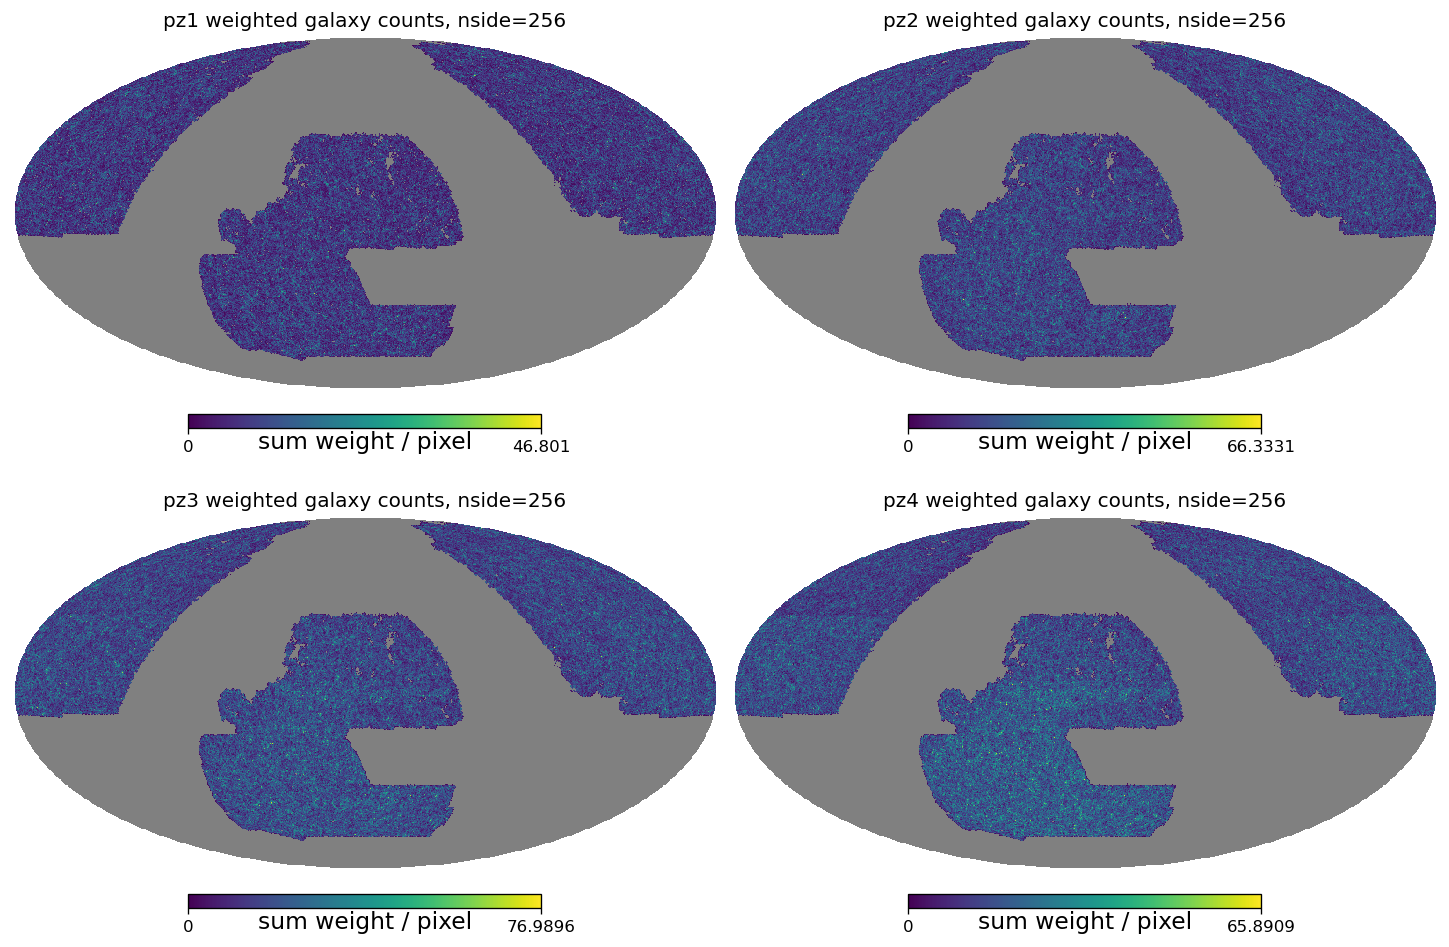

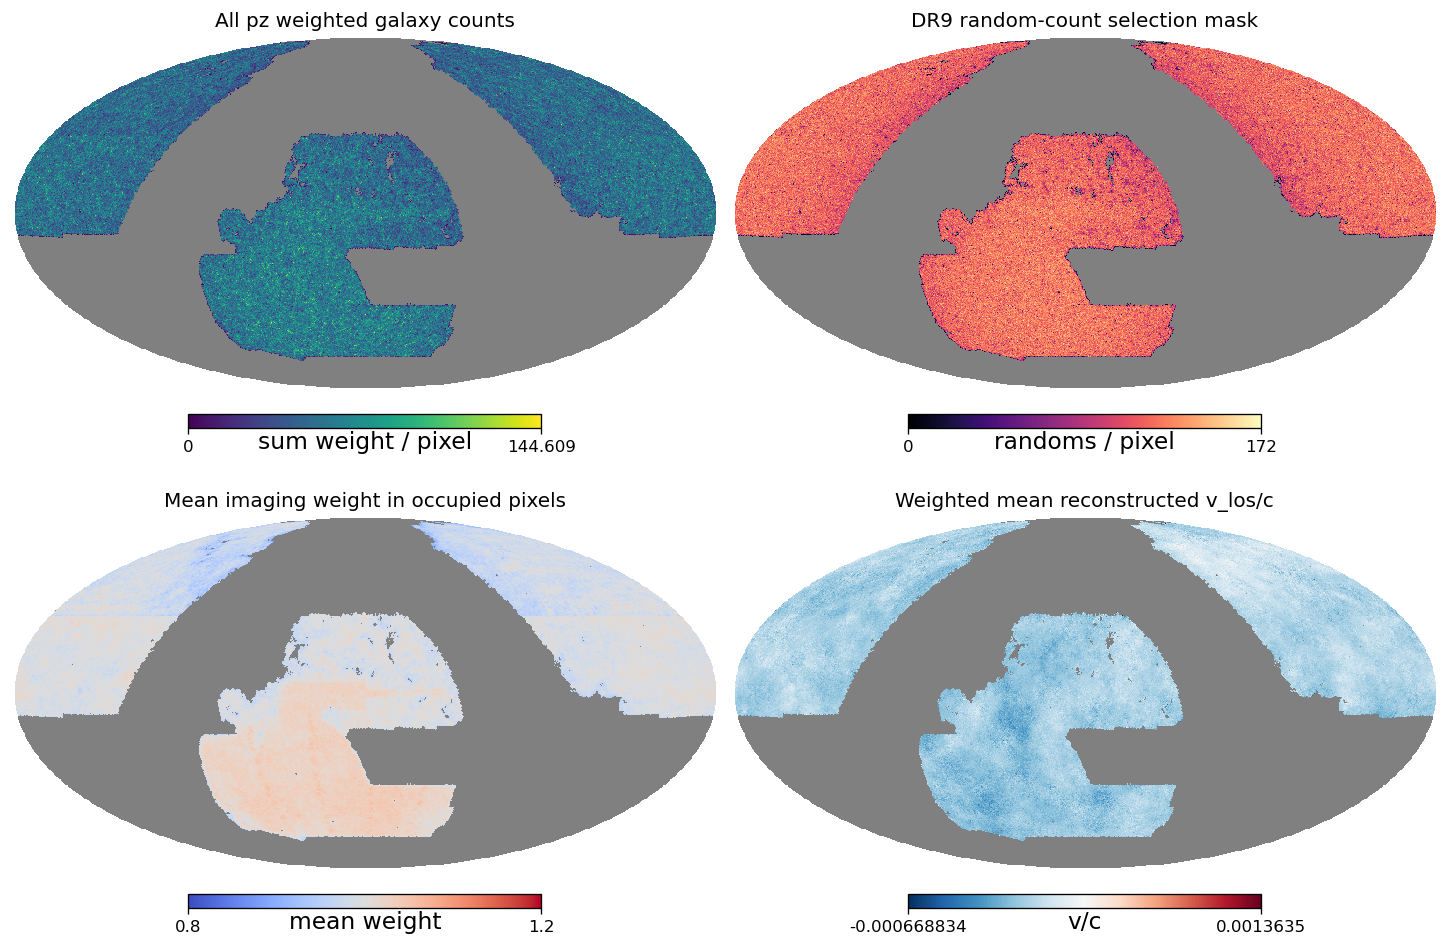

In [11]:
if hp is None:
    raise ImportError('healpy is required for sky maps')

fig = plt.figure(figsize=(12, 8))
for i, pz in enumerate(range(1, 5), start=1):
    hp.mollview(
        moll_array(per_bin_maps[pz]['sumw'], unseen_where=per_bin_maps[pz]['sumw'] <= 0),
        fig=fig.number,
        sub=(2, 2, i),
        title=f'pz{pz} weighted galaxy counts, nside={NSIDE_PLOT}',
        unit='sum weight / pixel',
        cmap='viridis',
        min=0,
    )
fig.savefig(OUTDIR / f'desi_dr9_ksz_cleaned_sky_by_pz_nside{NSIDE_PLOT}.png', bbox_inches='tight')
plt.show()

fig = plt.figure(figsize=(12, 8))
hp.mollview(
    moll_array(sumw, unseen_where=sumw <= 0),
    fig=fig.number,
    sub=(2, 2, 1),
    title='All pz weighted galaxy counts',
    unit='sum weight / pixel',
    cmap='viridis',
    min=0,
)
hp.mollview(
    moll_array(random_low, unseen_where=random_low <= 0),
    fig=fig.number,
    sub=(2, 2, 2),
    title='DR9 random-count selection mask',
    unit='randoms / pixel',
    cmap='magma',
    min=0,
)
hp.mollview(
    moll_array(mean_weight, unseen_where=~np.isfinite(mean_weight)),
    fig=fig.number,
    sub=(2, 2, 3),
    title='Mean imaging weight in occupied pixels',
    unit='mean weight',
    cmap='coolwarm',
    min=0.8,
    max=1.2,
)
hp.mollview(
    moll_array(mean_vr, unseen_where=~np.isfinite(mean_vr)),
    fig=fig.number,
    sub=(2, 2, 4),
    title='Weighted mean reconstructed v_los/c',
    unit='v/c',
    cmap='RdBu_r',
)
fig.savefig(OUTDIR / f'desi_dr9_ksz_cleaned_sky_distribution_nside{NSIDE_PLOT}.png', bbox_inches='tight')
plt.show()


## NaMaster Map-Making Recipe

Use the galaxy catalog and random-count maps together. A typical spin-0 overdensity map for one tomographic bin is:

```python
valid = catalog['valid_for_cl'][:]
w = catalog['weight_imaging_mean1'][:][valid]
pix = hp.ang2pix(nside, theta, phi, nest=False)
weighted_counts = np.bincount(pix, weights=w, minlength=hp.nside2npix(nside))
random_counts = h5['nside1024/random_count'][:]  # or nside4096
mask = random_counts > 0
alpha = weighted_counts[mask].sum() / random_counts[mask].sum()
delta_g = np.zeros_like(weighted_counts, dtype=float)
delta_g[mask] = weighted_counts[mask] / (alpha * random_counts[mask]) - 1.0
```

For production high-ell work, the one-random-realization `nside4096` mask is sparse. Smooth/apodize it, or combine additional DR9 random realizations before measuring high-resolution galaxy auto spectra.

For theory, use the same tomographic bin and the final kSZ theory group:

```text
ksz_paper_scaled_counts/dr9_extended_fiducial_outlier_and_photoz_correction_act_overlap/pz{bin}/nz_unit_integral
```

Use `n_per_redshift_bin_count` or `dndz_count` only if the theory code wants the final kSZ sample abundance/count distribution instead of a unit-normalized kernel.


In [12]:
summary = {
    'description': 'Validation summary for the DESI DR9 Extended LRG transfer catalogs and final kSZ-count-scaled theory n(z).',
    'path_convention': 'All paths are relative to the act_desi_ksz_transfer root unless explicitly marked as NERSC provenance.',
    'recommended_catalog_selection': 'catalog/valid_for_cl',
    'recommended_catalog_weight': 'catalog/weight_imaging_mean1',
    'recommended_random_mask': str(RANDOM_MAP_PATH.relative_to(ROOT)),
    'recommended_theory_nz_hdf5': str(NZ_PATH.relative_to(ROOT)),
    'recommended_theory_group': KSZ_GROUP,
    'recommended_normalized_kernel_dataset': 'nz_unit_integral',
    'recommended_count_dataset': 'n_per_redshift_bin_count',
    'shape_source_group': SHAPE_SOURCE_GROUP,
    'catalog_stats': catalog_stats,
    'nz_validation': nz_validation,
    'weight_hist_summary': weight_hist_summary,
    'sky_validation': sky_validation,
    'figures': {
        'nz_validation': 'diagnostics/desi_dr9_ksz_cleaned_catalog/desi_dr9_ksz_cleaned_nz_validation.png',
        'photoz_vs_true_nz': 'diagnostics/desi_dr9_ksz_cleaned_catalog/desi_dr9_photoz_vs_true_nz_diagnostic.png',
        'weight_validation': 'diagnostics/desi_dr9_ksz_cleaned_catalog/desi_dr9_ksz_cleaned_weight_validation.png',
        'sky_by_pz': f'diagnostics/desi_dr9_ksz_cleaned_catalog/desi_dr9_ksz_cleaned_sky_by_pz_nside{NSIDE_PLOT}.png',
        'sky_distribution': f'diagnostics/desi_dr9_ksz_cleaned_catalog/desi_dr9_ksz_cleaned_sky_distribution_nside{NSIDE_PLOT}.png',
    },
    'important_caveat': (
        'The object-level HDF5 catalogs are full valid DR9 Extended LRG footprint products. '
        'The final kSZ-paper ACT-overlap/velocity-outlier cleaning is represented in theory n(z) by count scaling. '
        'Apply any final object-level ACT/outlier selection consistently during map making if exact object-list matching is required.'
    ),
}

summary_path = OUTDIR / 'summary.json'
with open(summary_path, 'w') as f:
    json.dump(as_jsonable(summary), f, indent=2, sort_keys=True)
print('Wrote', summary_path.relative_to(ROOT))


Wrote diagnostics/desi_dr9_ksz_cleaned_catalog/summary.json


## Bottom Line

For the single-HOD theory comparison to the same kSZ-cleaned sample used for auto and cross correlations, the safest default is:

```text
data/desi_dr9_redshift_distributions/desi_dr9_extended_lrg_sigmaz0p05_true_nz.h5
ksz_paper_scaled_counts/dr9_extended_fiducial_outlier_and_photoz_correction_act_overlap/pz{1,2,3,4}/nz_unit_integral
```

This preserves the spectroscopic true-redshift calibration and uses the final kSZ-paper counts for the abundance. The object-level galaxy maps should use `valid_for_cl`, `weight_imaging_mean1`, and the DR9 random-count selection masks.
